In [1]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np
import scipy

from astropy.table import Table
import sys, os, tqdm, glob
wdmodels_dir = os.environ['WDMODELS_DIR']
sys.path.append(wdmodels_dir)
import WD_models

plt.style.use("stefan.mplstyle")
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage[T1]{fontenc}\usepackage{lmodern}\usepackage{amsmath}",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

In [2]:
def mass_from_loggteff(loggarray : np.array, teffarray : np.array, 
                       low_model = 'be', mid_model = 'be', high_model = 'be',
                       atm_type = 'H') -> np.array:
    """compute the radial velocity from radius and effective temperature
    """
    mass_sun, radius_sun, newton_G, speed_light = 1.9884e30, 6.957e8, 6.674e-11, 299792458
    font_model = WD_models.load_model(low_model, mid_model, high_model, atm_type) 
    g_acc = (10**font_model['logg'])/100
    rsun = np.sqrt(font_model['mass_array'] * mass_sun * newton_G / g_acc) / radius_sun
    rad_teff_to_mass = WD_models.interp_xy_z_func(x = font_model['logg'], y = 10**font_model['logteff'],\
                                                z = font_model['mass_array'], interp_type = 'linear')
    return rad_teff_to_mass(loggarray, teffarray)

In [3]:
data1 = pd.read_parquet("../omnidwarf/merges/ngf21_widebinaries_apogee.pqt")
data2 = pd.read_parquet("../omnidwarf/merges/ngf21_widebinaries_astra.pqt")
data3 = pd.read_parquet("../omnidwarf/merges/MWDDDB_widebinaries_astra.pqt").query("fe_h > -999 & flag_bad == False")


#vincent = pd.read_parquet("../../../catalogs/XP-spectra/vincent2024.pqt")
data_apogee = data1.query("FE_H > -999 & ALPHA_M_ERR < 0.1")
data_astra = data2.query("fe_h > -999 & flag_bad == False & e_alpha_m_atm < 0.1")
data_galah = pd.read_parquet("../omnidwarf/merges/ngf21_widebinaries_galah.pqt").query("e_fe_h < 0.1 & e_Mg_fe < 0.1")
len(data_galah), len(data_astra)+len(data_apogee)+len(data_galah)

(36, 495)

In [4]:
data_apogee["wd_age"] = 10**(data_apogee["log_age_best"] - 9)
data_apogee["wd_age_lo"] = 10**(data_apogee["log_age_lo_best"] - 9)
data_apogee["wd_age_hi"] = 10**(data_apogee["log_age_hi_best"] - 9)

data_apogee["wd_cool_age"] = 10**(data_apogee["log_age_cool_best"] - 9)
data_apogee["wd_cool_age_lo"] = 10**(data_apogee["log_age_cool_lo_best"] - 9)
data_apogee["wd_cool_age_hi"] = 10**(data_apogee["log_age_cool_hi_best"] - 9)

data_astra["wd_age"] = 10**(data_astra["log_age_best"] - 9)
data_astra["wd_age_lo"] = 10**(data_astra["log_age_lo_best"] - 9)
data_astra["wd_age_hi"] = 10**(data_astra["log_age_hi_best"] - 9)

data_astra["wd_cool_age"] = 10**(data_astra["log_age_cool_best"] - 9)
data_astra["wd_cool_age_lo"] = 10**(data_astra["log_age_cool_lo_best"] - 9)
data_astra["wd_cool_age_hi"] = 10**(data_astra["log_age_cool_hi_best"] - 9)


data_galah["wd_age"] = 10**(data_galah["log_age_best"] - 9)
data_galah["wd_age_lo"] = 10**(data_galah["log_age_lo_best"] - 9)
data_galah["wd_age_hi"] = 10**(data_galah["log_age_hi_best"] - 9)

data_galah["wd_cool_age"] = 10**(data_galah["log_age_cool_best"] - 9)
data_galah["wd_cool_age_lo"] = 10**(data_galah["log_age_cool_lo_best"] - 9)
data_galah["wd_cool_age_hi"] = 10**(data_galah["log_age_cool_hi_best"] - 9)

/tmp/ipykernel_46531/3294228736.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_apogee["wd_age"] = 10**(data_apogee["log_age_best"] - 9)
/tmp/ipykernel_46531/3294228736.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_apogee["wd_age_lo"] = 10**(data_apogee["log_age_lo_best"] - 9)
/tmp/ipykernel_46531/3294228736.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docu

In [5]:
def make_best(data):


    function = np.where(data["PDA"] > 0.5, "H", "He")
    mH = function == "H"
    mHe = function == "He"

    # ensure column exists
    data.loc[:,"mass_best"] = np.nan

    data.loc[mH, "mass_best"] = mass_from_loggteff(
        data.loc[mH, "logg_best"].to_numpy(),
        data.loc[mH, "teff_best"].to_numpy(),
        atm_type="H"
    )

    data.loc[mHe, "mass_best"] = mass_from_loggteff(
        data.loc[mHe, "logg_best"].to_numpy(),
        data.loc[mHe, "teff_best"].to_numpy(),
        atm_type="He"
    )
    return data
#data = #data.query("10000 < teff_best < 300000")
data_apogee_hot = make_best(data_apogee)#.query("18000 < teff_best")
data_astra_hot = make_best(data_astra)#.query("18000 < teff_best")
data_galah_hot = make_best(data_galah)

dawds_apogee = data_apogee_hot.query("PDA > 0.8")
dawds_astra = data_astra_hot.query("PDA > 0.8")
dawds_galah = data_galah_hot.query("PDA > 0.8")

dbwds_apogee = data_apogee_hot.query("PDB > 0.5")
dbwds_astra = data_astra_hot.query("PDB > 0.5")
dbwds_galah = data_galah_hot.query("PDA > 0.8")

print(f"DA WDs: {len(dawds_apogee) + len(dawds_astra) + len(dawds_galah)}")
print(f"DB WDs: {len(data3)}")

/tmp/ipykernel_46531/1255530223.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:,"mass_best"] = np.nan
/tmp/ipykernel_46531/1255530223.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:,"mass_best"] = np.nan


DA WDs: 311
DB WDs: 44


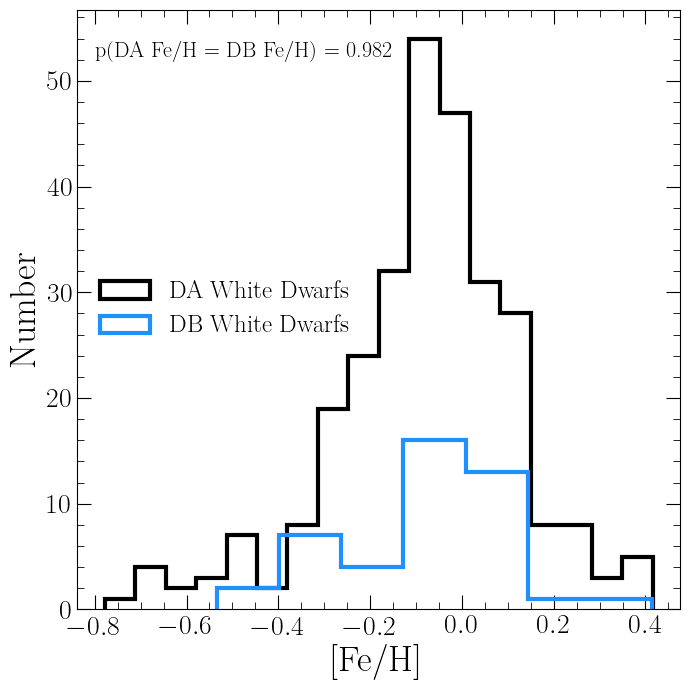

In [13]:
fig, ax = plt.subplots(ncols=1)

feh_all = np.append(dawds_apogee["FE_H"], dawds_astra["fe_h"])
e_feh_all = np.append(dawds_apogee["FE_H_ERR"], dawds_astra["e_fe_h"])
feh_all = feh_all[~np.isnan(feh_all)]

feh_dbs = np.append(dbwds_apogee["FE_H"], dbwds_astra["fe_h"])#, data3["fe_h"])
feh_dbs = data3["fe_h"]
feh_dbs = feh_dbs[~np.isnan(feh_dbs)]

ks_greater = scipy.stats.ks_2samp(feh_all, feh_dbs, alternative="greater", method='asymp')
ks_equal = scipy.stats.ks_2samp(feh_all, feh_dbs, alternative="two-sided", method='asymp')
ks_less = scipy.stats.ks_2samp(feh_all, feh_dbs, alternative="less", method='asymp')

y, bin_edges, _ = ax.hist(feh_all, histtype="step", linewidth=3, color="k", label="DA White Dwarfs");
y, bin_edges, _ = ax.hist(feh_dbs, histtype="step", linewidth=3, color="dodgerblue", label="DB White Dwarfs");
ax.set_xlabel("[Fe/H]") ; ax.set_ylabel("Number")
ax.legend(framealpha=0)

ax.text(
    0.03, 0.95, 
    rf"p(DA Fe/H $=$ DB Fe/H) = {ks_equal.pvalue:1.3f}",
    ha="left", va="top",
    fontsize=16, transform=ax.transAxes
)

fig.tight_layout()
fig.savefig("figures/massloss_metallicity.pdf")

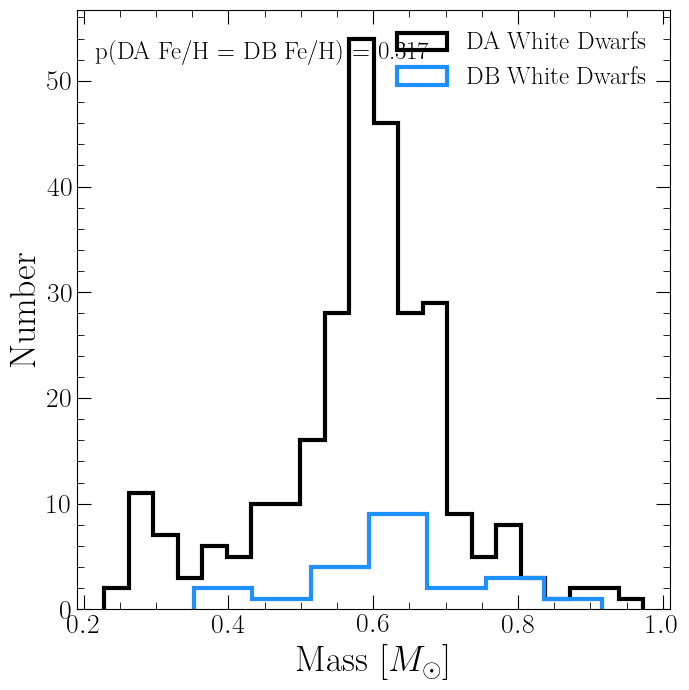

In [7]:
fig, ax = plt.subplots(ncols=1)

feh_all = np.append(dawds_apogee["mass_best"], dawds_astra["mass_best"])
e_feh_all = np.append(dawds_apogee["mass_best"], dawds_astra["mass_best"])
feh_all = feh_all[~np.isnan(feh_all)]

feh_dbs = np.append(dbwds_apogee["mass_best"], dbwds_astra["mass_best"])#, data3["fe_h"])
#feh_dbs = data3["mass_best"]
feh_dbs = feh_dbs[~np.isnan(feh_dbs)]

ks_greater = scipy.stats.ks_2samp(feh_all, feh_dbs, alternative="greater", method='asymp')
ks_equal = scipy.stats.ks_2samp(feh_all, feh_dbs, alternative="two-sided", method='asymp')
ks_less = scipy.stats.ks_2samp(feh_all, feh_dbs, alternative="less", method='asymp')

y, bin_edges, _ = ax.hist(feh_all, histtype="step", linewidth=3, color="k", label="DA White Dwarfs");
y, bin_edges, _ = ax.hist(feh_dbs, histtype="step", linewidth=3, color="dodgerblue", label="DB White Dwarfs");
ax.set_xlabel("Mass $[M_\\odot$]") ; ax.set_ylabel("Number")
ax.legend(framealpha=0)

ax.text(
    0.03, 0.95, 
    rf"p(DA Fe/H $=$ DB Fe/H) = {ks_equal.pvalue:1.3f}",
    ha="left", va="top",
    fontsize=18, transform=ax.transAxes
)

fig.tight_layout()
#fig.savefig("figures/massloss_metallicity.pdf")

In [8]:
dbwds_apogee[["teff_best", "logg_best", "mass_best"]]

,teff_best,logg_best,mass_best
17,17206.746826,8.050907,0.624437
70,14392.627661,8.015086,0.597913
82,13028.291590,7.650733,0.408724
108,10395.552841,7.981454,0.571449
110,10815.296148,8.084591,0.633859
123,15553.816610,7.962544,0.570907
125,14605.346070,8.106273,0.653713
130,15350.505089,8.199390,0.712317
131,11170.304936,8.036942,0.605250
147,24681.764528,7.857527,0.533293


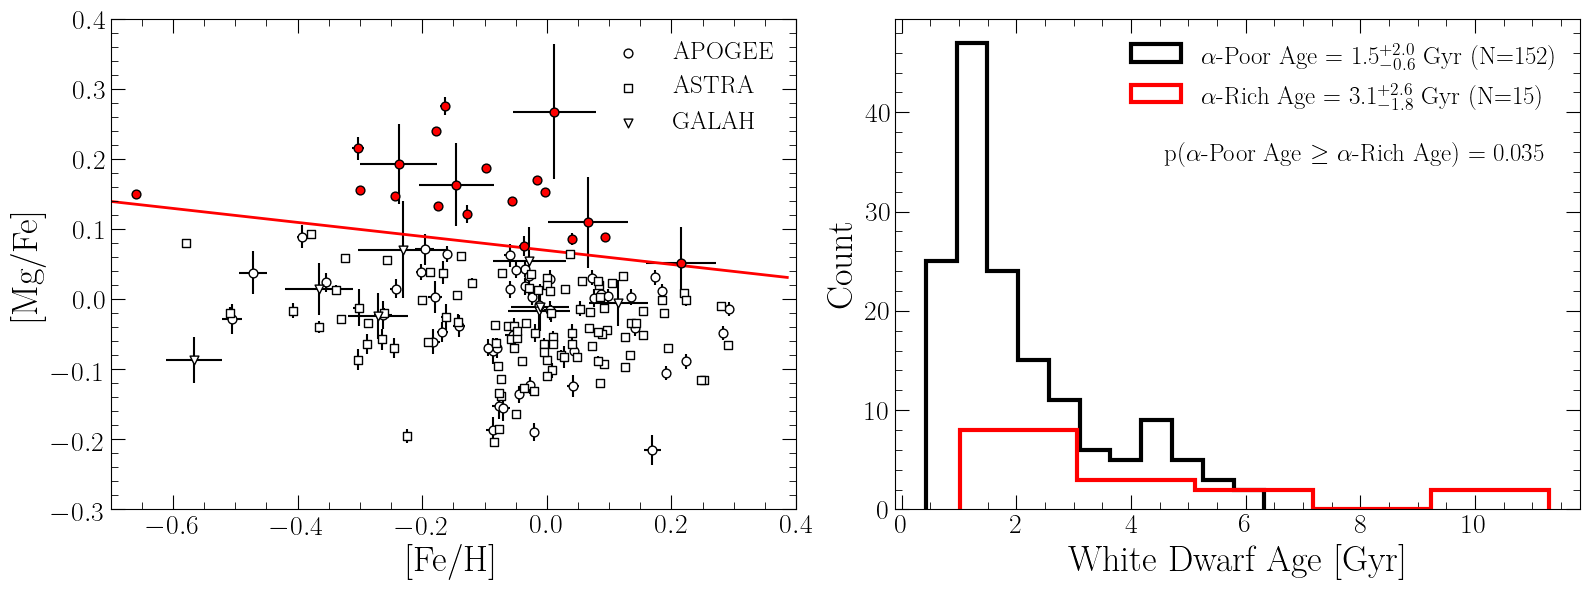

In [9]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(ncols=2, figsize=(16, 6))

# -------------------------
# APOGEE
# -------------------------
data_apogee = data_apogee.query("mass_best > 0.63").copy()

# mask: above the line y = -0.1 x + 0.1
mask_apogee = ((-0.1 * data_apogee["FE_H"] + 0.07) < data_apogee["MG_FE"])

# errorbars (all black)
ax[0].errorbar(
    data_apogee["FE_H"], data_apogee["MG_FE"], xerr=data_apogee["FE_H_ERR"], yerr=data_apogee["MG_FE_ERR"],
    c="k", fmt="None", zorder=0
)
# below line -> white
ax[0].scatter(
    data_apogee.loc[~mask_apogee, "FE_H"], data_apogee.loc[~mask_apogee, "MG_FE"],
    c="white", edgecolor="k", zorder=1, label="APOGEE", s=40
)
# above line -> red
ax[0].scatter(
    data_apogee.loc[mask_apogee, "FE_H"], data_apogee.loc[mask_apogee, "MG_FE"],
    c="red", edgecolor="k", zorder=2, s=40
)


# -------------------------
# ASTRA
# -------------------------
data_astra = data_astra.copy()
data_astra.loc[:, "mg_fe"] = data_astra["mg_h"] - data_astra["fe_h"]
data_astra.loc[:, "e_mg_fe"] = np.sqrt(data_astra["e_mg_h"]**2 + data_astra["e_fe_h"]**2)

data_astra = data_astra.query("mass_best > 0.63").copy()
mask_astra = ((-0.1 * data_astra["fe_h"] + 0.07) < data_astra["mg_fe"])

# errorbars (all black)
ax[0].errorbar(
    data_astra["fe_h"], data_astra["mg_fe"], xerr=data_astra["e_fe_h"], yerr=data_astra["e_mg_fe"],
    c="k", fmt="None", zorder=0
)
# below line -> white
ax[0].scatter(
    data_astra.loc[~mask_astra, "fe_h"], data_astra.loc[~mask_astra, "mg_fe"],
    c="white", edgecolor="k", zorder=1, marker="s", label="ASTRA", s=40
)
# above line -> red
ax[0].scatter(
    data_astra.loc[mask_astra, "fe_h"], data_astra.loc[mask_astra, "mg_fe"],
    c="red", edgecolor="k", zorder=2, s=40
)

# -------------------------
# GALAH
# -------------------------
data_galah = data_galah.copy()

data_galah = data_galah.query("mass_best > 0.63").copy()
mask_galah = ((-0.1 * data_galah["fe_h"] + 0.07) < data_galah["Mg_fe"])

# errorbars (all black)
ax[0].errorbar(
    data_galah["fe_h"], data_galah["Mg_fe"], xerr=data_galah["e_fe_h"], yerr=data_galah["e_Mg_fe"],
    c="k", fmt="None", zorder=0
)
# below line -> white
ax[0].scatter(
    data_galah.loc[~mask_galah, "fe_h"], data_galah.loc[~mask_galah, "Mg_fe"],
    c="white", edgecolor="k", zorder=1, marker="v", label="GALAH", s=40
)
# above line -> red
ax[0].scatter(
    data_galah.loc[mask_galah, "fe_h"], data_galah.loc[mask_galah, "Mg_fe"],
    c="red", edgecolor="k", zorder=2, s=40
)


# -------------------------
# Decision boundary line
# -------------------------
xx = np.array(ax[0].get_xlim())
ax[0].plot(xx, -0.1 * xx + 0.07, c="red", lw=2, zorder=0)
ax[0].set_xlim(xx)

ax[0].set_ylim(-0.3, 0.4)
ax[0].set_xlim(-0.7, 0.4)
ax[0].set_xlabel("[Fe/H]")
ax[0].set_ylabel("[Mg/Fe]")
ax[0].legend(framealpha=0)


# -------------------------
# Histogram split by the same masks
# -------------------------
age_hi = np.concatenate((
    data_apogee.loc[mask_apogee, "wd_age"].to_numpy(),
    data_astra.loc[mask_astra, "wd_age"].to_numpy(),
    #data_galah.loc[mask_galah, "wd_age"].to_numpy(),
))
age_lo = np.concatenate((
    data_apogee.loc[~mask_apogee, "wd_age"].to_numpy(),
    data_astra.loc[~mask_astra, "wd_age"].to_numpy(),
    #data_galah.loc[~mask_galah, "wd_age"].to_numpy(),
))

pct_hi = np.percentile(age_hi, [16, 50, 84])
pct_lo = np.percentile(age_lo, [16, 50, 84])

ax[1].hist(age_lo, density=False, color="k", histtype="step", linewidth=3,
           label=f"$\\alpha$-Poor Age = {pct_lo[1]:2.1f}$_{{-{pct_lo[1]-pct_lo[0]:2.1f}}}^{{+{pct_lo[2]-pct_lo[1]:2.1f}}}$ Gyr (N={len(age_lo)})")
ax[1].hist(age_hi, density=False, color="red", histtype="step", linewidth=3,
           label=f"$\\alpha$-Rich Age = {pct_hi[1]:2.1f}$_{{-{pct_hi[1]-pct_hi[0]:2.1f}}}^{{+{pct_hi[2]-pct_hi[1]:2.1f}}}$ Gyr (N={len(age_hi)})")

ks_equal = scipy.stats.ks_2samp(age_hi, age_lo, alternative="less", method='asymp')
ax[1].text(
    0.95, 0.75, 
    rf"p($\alpha$-Poor Age $\geq$ $\alpha$-Rich Age) = {ks_equal.pvalue:1.3f}",
    ha="right", va="top",
    fontsize=18, transform=ax[1].transAxes
)

ax[1].legend(framealpha=0)
ax[1].set_xlabel("White Dwarf Age [Gyr]")
ax[1].set_ylabel("Count")

fig.tight_layout()
fig.savefig("figures/metallicity_age.pdf")

In [10]:
age_hi = age_hi[age_hi < 8]
ks_equal = scipy.stats.ks_2samp(age_hi, age_lo, alternative="less", method='asymp')
print(ks_equal.pvalue)

0.13354300775665273
